In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
import mesa_web as mw

# Investigating MESA stellar models 

### We are using an online web interface presented here: 

http://user.astro.wisc.edu/~townsend/static.php?ref=mesa-web-submit

### MESA stands for: Modules for Experiments in Stellar Astrophysics

### You can learn more about the code here: 

https://docs.mesastar.org/en/latest/

### Today, we will pretend that we are stellar astrophysicists and we will analyze the output and stellar evolution.



### 1) For a first assignment: Look at the job submission tool and discuss the following: 

#### 1a) What are the physical inputs that you have already expected? 

#### 1b) What are the physical inputs that are new to us? What new physics can MESA treat? 

#### 1c) What "hyperparameters" are there, and what are they for? 

#### 1d) What about numerical details?



### 2) Everyone submit their own job

#### List below: 

Ivan - 4 solar masses, metallicity = blabla, 

#### These jobs will take some time, so in the meantime, look for the results here: 

### 3) Analyze the output of pre-prepared models: 

https://drive.google.com/drive/folders/1K0fUb77799BqA6r4COhIJal_J0c86kpq?usp=sharing

Each evolutionary track or however you want to call it, consists of series of models, that is 'profiles'. 

We have two kinds of output: 

### History output
The history file, named trimmed_history.data, provides general information about the entire stellar model as a function of time. The file consists of a few header lines giving global data, followed by a sequence of rows correspond to individual timesteps. The columns of each row contain the following data (look at the webpage)

### Profiles output:

Profile Output
The profile files, named profileN.dat (where N is an integer counting up from 1), contain information about the internal structure of the stellar model at a single timestep. The mapping between profile number N and timestep is provided in the file named profiles.index. A profile file consists of a few header lines giving global data, followed by a sequence of rows correspond to individual interior zones (ordered from the outermost zone to the innermost). The columns of each row contain the following data:

### Summary of python stuff:

read_history() read a history file.

read_profile() read a profile file.

find_read_profile() find a profile file using the profiles.index mapping file, and then read it.

In [4]:
# HISTORY OUTPUT:

hf = mw.read_history('/home/milic/data/MESA/Model_1/trimmed_history.data')

In [5]:
hf.keys()

dict_keys(['version_number', 'compiler', 'build', 'MESA_SDK_version', 'math_backend', 'date', 'burn_min1', 'burn_min2', 'model_number', 'star_age', 'star_mass', 'log_L', 'log_R', 'log_Teff', 'log_center_T', 'log_center_Rho', 'log_center_P', 'center_h1', 'center_he3', 'center_he4', 'center_c12', 'center_n14', 'center_o16', 'center_ne20', 'center_mg24', 'center_si28', 'center_s32', 'center_ar36', 'center_ca40', 'center_ti44', 'center_cr48', 'center_fe52', 'center_fe54', 'center_fe56', 'center_ni56', 'center_degeneracy', 'center_ye', 'center_entropy', 'compactness_parameter', 'dynamic_timescale', 'kh_timescale', 'nuc_timescale', 'pp', 'cno', 'tri_alfa', 'log_LH', 'log_LHe', 'log_LZ', 'log_Lneu', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'si_core_mass', 'fe_core_mass', 'he_core_radius', 'c_core_radius', 'o_core_radius', 'si_core_radius', 'fe_core_radius', 'max_abs_v_velocity', 'surf_avg_omega_div_omega_crit', 'log_total_angular_momentum', 'surf_avg_omega', 'surf_avg_v_rot', 'star_mdot'

#### Inspect a few fundamental stellar parameters

In [9]:
star_mass = hf['star_mass']

In [10]:
star_mass

array([1.        , 1.        , 1.        , ..., 0.56201913, 0.56201913,
       0.56201913])

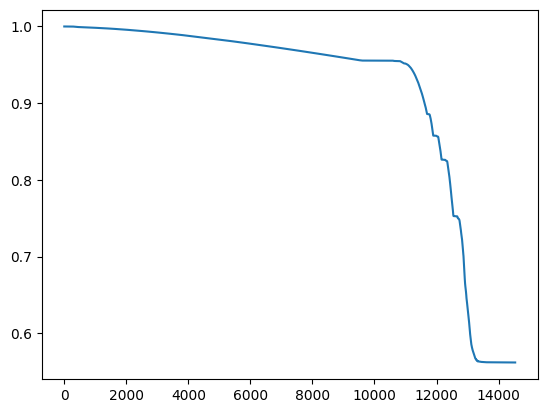

In [11]:
plt.plot(star_mass)

In [12]:
log_L = hf['log_L']

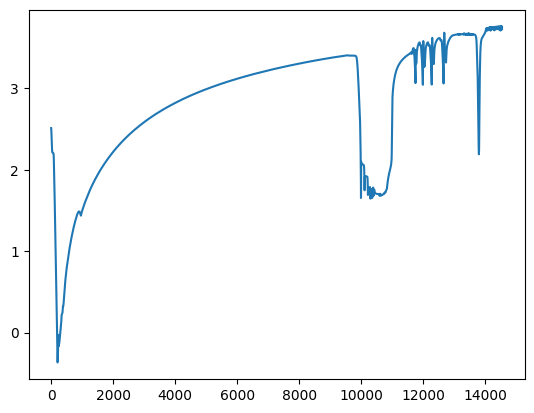

In [14]:
plt.plot(log_L)

In [16]:
log_R = hf['log_R']

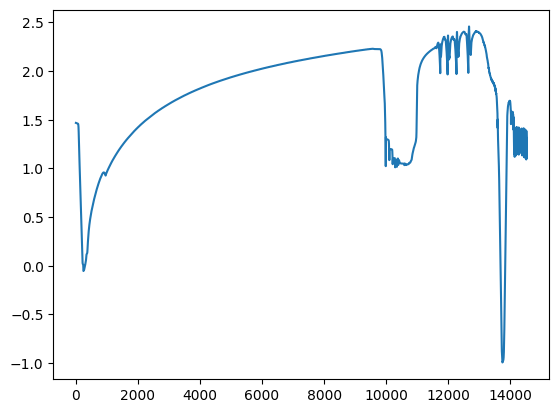

In [17]:
plt.plot(log_R)

### Discuss what is happening here, why are things changing so 'fast'? 

Keep in mind the x axis is the "step" - NOT linear scaling with time! 

#### Can someone guess what kind of star we have been simulating here? 

#### Open the appropriate history file in the folder to check your answer:

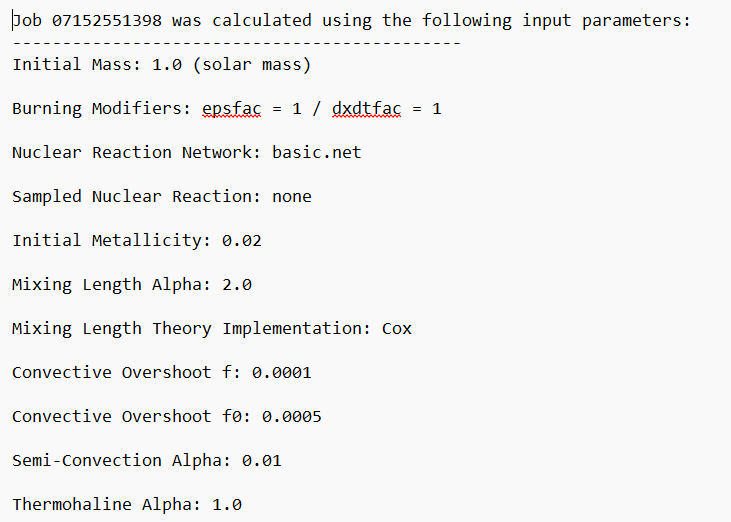

In [18]:
star_age = hf['star_age']

In [19]:
star_age

array([1.00000000e-05, 2.20000000e-05, 3.64000000e-05, ...,
       1.24763265e+10, 1.24763265e+10, 1.24763265e+10])

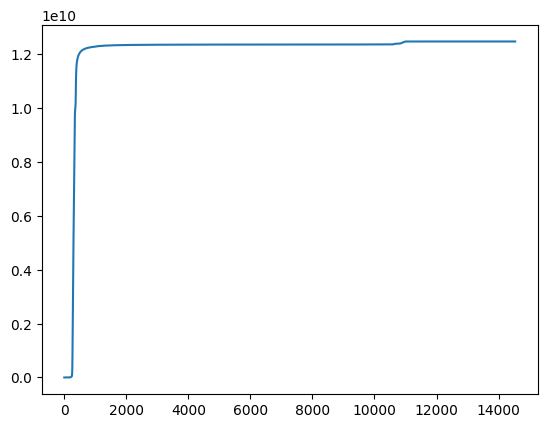

In [20]:
plt.plot(star_age)

### According to all this, try to isolate one instance on the main sequence and plot the stellar structure there! 

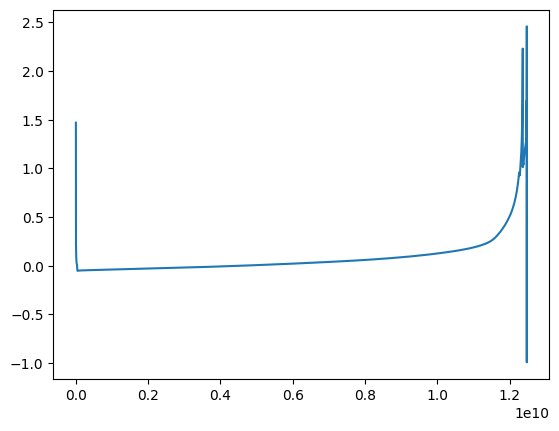

In [21]:
plt.plot(star_age, log_R)

### Where is the star formation phase? Where is the main sequence? Where are the late stages? 

### Find the moment when the star is 1 Billion years old: 

In [23]:
np.argmin(np.abs(star_age - 1E9))

266

### Read the profile:

In [24]:
ms = mw.read_profile('/home/milic/data/MESA/Model_1/profile266.data')

In [25]:
ms.keys()

dict_keys(['model_number', 'num_zones', 'initial_mass', 'initial_z', 'star_age', 'time_step', 'Teff', 'photosphere_L', 'photosphere_r', 'center_eta', 'center_h1', 'center_he3', 'center_he4', 'center_c12', 'center_n14', 'center_o16', 'center_ne20', 'star_mass', 'star_mdot', 'star_mass_h1', 'star_mass_he3', 'star_mass_he4', 'star_mass_c12', 'star_mass_n14', 'star_mass_o16', 'star_mass_ne20', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'si_core_mass', 'fe_core_mass', 'neutron_rich_core_mass', 'tau10_mass', 'tau10_radius', 'tau100_mass', 'tau100_radius', 'dynamic_time', 'kh_timescale', 'nuc_timescale', 'power_nuc_burn', 'power_h_burn', 'power_he_burn', 'power_neu', 'burn_min1', 'burn_min2', 'time_seconds', 'version_number', 'compiler', 'build', 'MESA_SDK_version', 'math_backend', 'date', 'mass', 'radius', 'luminosity', 'pressure', 'logRho', 'logT', 'energy', 'entropy', 'cp', 'gamma1', 'grada', 'mu', 'free_e', 'ye', 'pgas', 'prad', 'gradr', 'gradT', 'velocity', 'conv_vel', 'opacity', 'eps

In [26]:
ms['Teff']

3008.1077010619447

In [27]:
ms['photosphere_L']

4516.833302735513

In [29]:
ms['star_age'] / 1E9

12.47630542245441

### Can anyone figure what was going on? 

In [30]:
hf = mw.read_history('/home/milic/data/MESA/Model_1_short/trimmed_history.data')

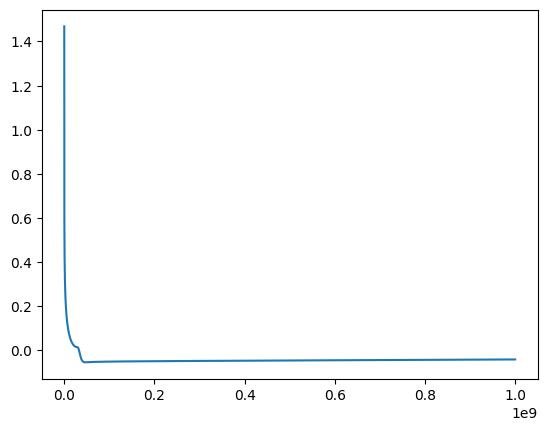

In [31]:
star_age = hf['star_age']
log_R = hf['log_R']

plt.plot(star_age, log_R)

In [32]:
np.argmin(np.abs(star_age - 1E9))

266

In [33]:
len(star_age)

267

In [38]:
ms = mw.read_profile('/home/milic/data/MESA/Model_1_short/profile56.data')

In [39]:
ms.keys()

dict_keys(['model_number', 'num_zones', 'initial_mass', 'initial_z', 'star_age', 'time_step', 'Teff', 'photosphere_L', 'photosphere_r', 'center_eta', 'center_h1', 'center_he3', 'center_he4', 'center_c12', 'center_n14', 'center_o16', 'center_ne20', 'star_mass', 'star_mdot', 'star_mass_h1', 'star_mass_he3', 'star_mass_he4', 'star_mass_c12', 'star_mass_n14', 'star_mass_o16', 'star_mass_ne20', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'si_core_mass', 'fe_core_mass', 'neutron_rich_core_mass', 'tau10_mass', 'tau10_radius', 'tau100_mass', 'tau100_radius', 'dynamic_time', 'kh_timescale', 'nuc_timescale', 'power_nuc_burn', 'power_h_burn', 'power_he_burn', 'power_neu', 'burn_min1', 'burn_min2', 'time_seconds', 'version_number', 'compiler', 'build', 'MESA_SDK_version', 'math_backend', 'date', 'mass', 'radius', 'luminosity', 'pressure', 'logRho', 'logT', 'energy', 'entropy', 'cp', 'gamma1', 'grada', 'mu', 'free_e', 'ye', 'pgas', 'prad', 'gradr', 'gradT', 'velocity', 'conv_vel', 'opacity', 'eps

In [40]:
ms['Teff']

5644.369052488932

In [41]:
ms['photosphere_L']

0.7565599439910481

In [42]:
ms['star_age'] / 1E9

1.0

### If the time allows plot variables from the core to the edge! 

In [43]:
logT = ms['logT']

In [44]:
logT.shape

(470,)